In [1]:
import pandas as pd
from emoji import is_emoji
import json
import seaborn as sns
import matplotlib.pyplot as plt
import re
import os
from tdm import *
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk import word_tokenize,pos_tag
from nltk.corpus import wordnet as wn
from collections import Counter
from tqdm import tqdm

def sortedByValue( dict , ascending = True ):
    if ascending: 
        return {k: v for k, v in sorted(dict.items(), key=lambda item: item[1])}
    else:
        return {k: v for k, v in reversed( sorted(dict.items(), key=lambda item: item[1]))}

def clean(text):
    text = re.sub(r'[.]','. ',text)
    text = re.sub(r'\b\d+\b','',text)
    text = re.sub(r'[-]\b','',text)
    text = re.sub(r'\b[-]','',text)
    text = re.sub(r'\s+',' ',text)
    return text.lower()
    
import string
punctuation_marks = [char for char in string.punctuation]

from nltk.corpus import stopwords
stopword_list = stopwords.words('english')
stopword_list.extend(['``','\'s','\'\'','n\'t'])
stopword_list.extend(['und','der','de','die','bir','un','di','en','das','la','que','het','che','een','una','den','da','ist','es'])
stopword_list.extend(['van','il','zu','ich','mit','sich','ein','del','eine','el','bu','och','nicht','se','er','sie'])
stopword_list.extend(['e','als','som','dat','ik','det','att','su','con','auch','lucas','nesta'])
stopword_list.extend(['dem','bjørgvin','jag','non','auf','translated','si','zijn','von','ir','je','wie'])

for mark in string.punctuation + '“”’—‘':
    stopword_list.append(mark)
    
def remove_punctuation_and_stopwords(words):
    new_list= []
    for w in words:
        if w.isalnum() and w not in stopword_list:
            new_list.append( w )
    return new_list

def wordnet_hypernyms(token):
    all_hypernyms = []

    word_senses = wn.synsets(token)
    hypernyms = lambda s: s.hypernyms()
    for ws in word_senses:
        hypernyms = [hyp.name() for hyp in list(ws.closure(hypernyms))]
        all_hypernyms.extend(hypernyms)
    return all_hypernyms

def intersection(list1,list2):
    return list(set(list1) & set(list2))
    
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer 
#from nltk.sentiment.vader import SentimentIntensityAnalyzer

ana = SentimentIntensityAnalyzer()

In [2]:
corpus_literary = []
corpus_popular = []

json_data = json.load(open('reviews.json',encoding='utf-8'))
for review in json_data:
    if review['type'] == 'literary fiction':
        corpus_literary.append(review['text'])
    elif review['type'] == 'popular fiction':
        corpus_popular.append(review['text'])
        
print(f'The literary fiction corpus contains {len(corpus_literary)} reviews')
print(f'The popular fiction corpus contains {len(corpus_popular)} reviews')


The literary fiction corpus contains 4657 reviews
The popular fiction corpus contains 8503 reviews


## Textual analysis

In [3]:
selected_tags = [ 'JJ',
'JJR',
'JJS ',
'MD',
'NN',
'NNS',
'POS',
'PRP',
'PRP$ ',
'RB',
'RBR',
'RBS',
'VB',
'VBD',
'VBG',
'VBN',
'VBP',
'VBZ' ]

print('Analyzing literary fiction reviews ... ')

lf_words = Counter()
lf_reviews = ''
    
for review in tqdm(corpus_literary):
    lf_reviews += review + ' '
    words = word_tokenize(clean(review))
    words = remove_punctuation_and_stopwords(words)
    tags = pos_tag(words)
    selected_words = []
    for word,tag in tags:
        if tag in selected_tags:
            selected_words.append(word)
    lf_words.update(selected_words)
        
print('Analyzing popular fiction reviews ... ')
        
pf_words = Counter()
pf_reviews = ''
    
for review in tqdm(corpus_popular):
    pf_reviews += review + ' '
    words = word_tokenize(clean(review))
    words = remove_punctuation_and_stopwords(words)
    tags = pos_tag(words)
    selected_words = []
    for word,tag in tags:
        if tag in selected_tags:
            selected_words.append(word)
    pf_words.update(selected_words)

Analyzing literary fiction reviews ... 


100%|██████████████████████████████████████| 4657/4657 [00:36<00:00, 127.39it/s]


Analyzing popular fiction reviews ... 


100%|██████████████████████████████████████| 8503/8503 [00:59<00:00, 143.03it/s]


## Most frequent words 

30 most frequent words in litery fiction reviews.

In [4]:
for word,count in lf_words.most_common(30):
    print(f'{word} => {count}')

book => 7421
novel => 4022
story => 3874
read => 3494
life => 2848
also => 2407
time => 2240
much => 2091
would => 2075
people => 2012
way => 2005
characters => 1997
even => 1940
really => 1854
family => 1850
first => 1659
writing => 1601
think => 1579
author => 1563
could => 1536
many => 1534
booker => 1526
reading => 1513
world => 1478
well => 1358
love => 1351
know => 1291
character => 1291
us => 1284
felt => 1272


30 most frequent words in popular fiction reviews.

In [5]:
for word,count in pf_words.most_common(30):
    print(f'{word} => {count}')

book => 17276
read => 7311
story => 6367
characters => 5055
series => 4663
books => 4556
love => 4518
time => 4242
much => 4240
really => 4004
would => 3940
also => 3818
even => 3663
get => 3494
way => 3302
good => 3280
first => 3257
character => 3033
know => 3004
could => 2944
think => 2806
reading => 2735
life => 2607
well => 2537
plot => 2532
many => 2488
still => 2464
loved => 2442
people => 2400
felt => 2324


## Unique words

Which words in popular fiction reviews are NEVER used in literary fiction reviews? The list only shows the 50 most frequent unique words.

In [6]:
count = 0
for word in pf_words.keys():
    if word not in lf_words.keys():
        count+=1
        print(word)
        if count==50:
            break

amos
boggart
jamison
baldacci
frederica
draymont
mrsleif
macmillian
crosshairs
hardtogetalongwith
hindrance
expartner
amenable
wad
schlepping
requestion
lateral
preponderance
guesswork
cranks
byline
dumbed
churn
deckers
opinon
grisham
bogart
reassigned
talbott
blindfold
smoldering
acclimation
worndown
antisocial
counsel
tae
kwon
peeling
afterglow
injecting
terminate
tripe
slob
incapacitated
amazes
kyf
brewer
cassidy
bummed
gamma


Which words in literary fiction reviews are NEVER used in popular fiction reviews? The list only shows the 50 most frequent unique words.

In [7]:
count = 0
for word in lf_words.keys():
    if word not in pf_words.keys():
        count+=1
        print(word)
        if count==50:
            break

delirious
meister
eckhart
oxfordweidenfeld
basin
pew
ales
septology
vivii
damion
searls
fosse
fitzcarraldo
originals
asle
iiiv
clippings
visualising
easel
crates
beyer
cosiest
cafés
bjorgvin
timeslippage
mediumlength
guro
herdis
eiliv
siv
selfrun
exhibition
jenem
sein
gottes
nämlich
gott
allem
unterschiedenheit
dort
wollte
erkannte
selber
willens
diesen
menschen
schaffen
darum
ursache
meiner


## Distinctive words

One of statistical methods that can be used to find such distinctive words is Dunning’s log likelihood. In short, it analyses the distinctiveness of word in one set of texts compared to the texts in a reference corpus, by calculating probabilities based on word frequencies. A good explanation of the fomula can be found on the [wordHoard](https://wordhoard.northwestern.edu/userman/analysis-comparewords.html#loglike) website.

Using the frequencies that have been calculated above, the Dunning log likelihood scores are calculated for all of the words that occur both in corpus1 and corpus2 in the cell below. The actual calculation takes place in a method named `log_likelihood()`. The scores that are calculated are all stored in a dictionary named ll_scores

The formula that is implemented in the log_likelihood method returns a number which can either be positive or negative. A postive score indicates that there is a high probability that the word will be used in the first corpus. A negative probability indicates that occurence of the word is more common in the second corpus. The tokens that are assigned the highest scores, in other words, are also most distincive of the first corpus.

The code below lists the words that are assigned a positive log likelihood score in the first corpus.

See also [TDM tutorial, chapter on Diction](https://cdsleiden.github.io/tdm-tutorial/notebooks/9%20Diction.html)

In [8]:
total1 = sum(lf_words.values())
total2 = sum(pf_words.values())

Which words are distinctive for the literary fiction reviews?

In [9]:
ll_scores = dict()

for word in lf_words.keys():
    if word in pf_words.keys():

        ll_score = log_likelihood( lf_words[word] , pf_words[word] , total1 , total2 )
        ll_scores[word] = ll_score

max = 25
i = 0 
        
for word in sortedByValue(ll_scores , ascending = False ):
    print( word , ll_scores[word] )
    i += 1
    if i == max: 
        break  

booker 2729.484823442298
prize 1756.9672856465972
novel 1580.824833752124
narrator 846.7441913708454
longlist 729.8849555971086
longlisted 517.1669183115514
shortlisted 514.4303213997715
narrative 510.6116593650278
mother 497.8965319324477
prose 496.08246977741504
translation 484.47666471895144
lives 441.65981696708536
language 434.7144018641044
english 429.30500511506216
international 409.93754504330684
life 403.11836413165906
history 398.1273419366187
literary 362.8155259786791
sunday 350.8460968103179
literature 349.79792905628074
shortlist 339.8427927377172
debut 330.975355863861
shuggie 330.41100589598165
agnes 297.67617853808065
lucy 258.9550635209316


Which words are distinctive for the popular fiction reviews?

In [10]:
max = 25
i = 0 

for word in sortedByValue(ll_scores ) :
    print( word , ll_scores[word] )
    i += 1
    if i == max:
        break   

series -3163.6360962470003
books -1104.1087703890712
romance -1065.7757822304006
book -818.9511414176095
love -659.9448390223995
thriller -612.5805117659847
murder -553.5951905939654
king -522.6715461850588
violet -508.67803085021296
favorite -477.32468596932125
good -474.7505585018988
eve -461.29760952030324
henry -439.6214946143127
plot -438.6973775994019
emily -408.0361128353707
killer -408.03328436336153
loved -402.6512971135181
twists -365.45114028875764
holly -363.75039234027054
james -348.04655364444176
characters -338.67772219499807
action -331.42721913974566
hannah -329.479258578313
jack -323.00677322581157
hunt -315.5012432882948


## Hypernyms for cognitive processes

In [33]:
cognitive_processes = ['think.v.01','consideration.n.01',
'deliberation.n.02',  'higher_cognitive_process.n.01' ] 

import warnings
warnings.filterwarnings("ignore")

data = []
lexicon_literary = Counter()
lexicon_popular = Counter()

row = []
total = 0
cognition = 0

for word,count in lf_words.most_common():
    
    total += count 
    hypernyms = wordnet_hypernyms(word)
    if intersection(hypernyms,cognitive_processes):
        print(f"{word} ({count})")
        lexicon_literary.update([word])
        cognition += count

row.append('literary fiction')
row.append(cognition)
row.append(total)
data.append(row)
    
row = []
total = 0
cognition = 0

for word,count in pf_words.most_common():
    
    total += count 
    hypernyms = wordnet_hypernyms(word)
    if intersection(hypernyms,cognitive_processes):
        print(f"{word} ({count})")
        lexicon_popular.update([word])
        cognition += count

row.append('popular fiction')
row.append(cognition)
row.append(total)
data.append(row)

cognition_df = pd.DataFrame(data,columns=['type','cognition','total'])
cognition_df['cognition_perc'] = (cognition_df['cognition']/cognition_df['total'])*100
cognition_df['total_perc'] = (cognition_df['total']/cognition_df['total'])*100

think (1579)
reading (1513)
know (1291)
feel (1185)
find (797)
sense (709)
feels (612)
thinking (283)
finds (228)
possible (223)
knows (192)
understanding (180)
favorite (179)
pick (174)
choice (157)
thinks (142)
knowing (123)
impossible (112)
choices (111)
reflection (101)
considered (80)
consider (77)
meditation (66)
theory (63)
considering (59)
awareness (51)
musings (50)
regarding (49)
reflections (48)
admire (47)
grasp (43)
ken (43)
admired (39)
investigation (36)
implications (36)
alternative (34)
studying (33)
senses (31)
test (31)
viewed (28)
rewarding (28)
recognise (27)
apartheid (27)
introspection (25)
appreciation (25)
considers (25)
theories (22)
consideration (20)
judging (20)
reckoning (20)
guessing (19)
picks (18)
meditations (17)
analogy (17)
deciding (16)
deemed (16)
rewarded (16)
favorites (16)
grasping (15)
realization (15)
comprehension (15)
experimentation (14)
reconsider (12)
regarded (12)
recognised (12)
hindsight (11)
derivative (11)
foreshadowing (11)
integral

In [34]:
cognition_df.head()

,type,cognition,total,cognition_perc,total_perc
0,literary fiction,11735,572551,2.049599,100.0
1,popular fiction,20487,904220,2.265710,100.0


In [14]:
for word in list(lexicon_literary.keys()):
    if word not in list(lexicon_popular.keys()):
        print(word)

apartheid
imperialism
musing
zionism
recognising
rationalizations
relativity
abstracted
reputed
romanticising
dignified
honouring
extrapolation
rethinking
inference
projections
understandings
reductionism
envying
interferences
presupposition
venerated
poll
impossibles
rethinks
deifying
perusing
introspections
obverse
awarenesses
approximations
digitisation
treasuring
differentials
groupthink
reifying


In [15]:
for word in list(lexicon_popular.keys()):
    if word not in list(lexicon_literary.keys()):
        print(word)

guesswork
deems
estimate
holism
foreshadowings
glamorize
pyromancy
retrospects
rationales
embargo
underestimates
cull
factoring
reconsiders
reconsidering
rationalization
deeming
regress
syllogism
advisement


In [16]:
lexicon_terms = list(lexicon_literary.keys())
lexicon_terms.extend( list(lexicon_popular.keys()) )

In [17]:
out = open('cognition_literary.txt','w',encoding='utf-8')

for review in corpus_literary:
    words = word_tokenize(review)
    words = remove_punctuation_and_stopwords(words)
    if len(intersection(words,lexicon_terms))>0:
        out.write(review)
        out.write(f" [{'-'.join(intersection(words,lexicon_terms))}]\n\n")
        
out.close()

out = open('cognition_popular.txt','w',encoding='utf-8')

for review in corpus_popular:
    words = word_tokenize(review)
    words = remove_punctuation_and_stopwords(words)
    if len(intersection(words,lexicon_terms))>0:
        out.write(review)
        out.write(f" [{'-'.join(intersection(words,lexicon_terms))}]\n\n")
        
out.close()

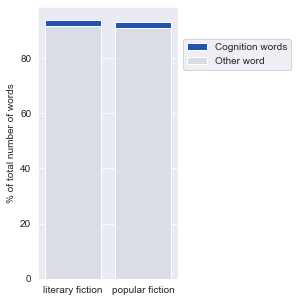

In [39]:
fig = plt.figure( figsize=( 2.5 , 5 ) )

bar_plot = sns.barplot(x='type', y='total_perc', label = 'Cognition words', data=cognition_df, color='#0a4cc7')
cognition_df['total_perc'] -=  cognition_df['cognition_perc']
bar_plot = sns.barplot(x='type', y='total_perc', label = 'Other word', data=cognition_df, color='#d8dde6')

bar_plot.set_xlabel('')
bar_plot.set_ylabel('% of total number of words')

bar_plot.legend(bbox_to_anchor=(1.0, 0.9))

# show the graph
plt.savefig('cognition_words.png',dpi=600, bbox_inches='tight')

## Sentiment Analysis

In [18]:
sentiment_lf = dict()

positive = []
negative = []

for word in lf_words.keys(): 
    word = re.sub(r'[\'-]' , '' , word)

    scores = ana.polarity_scores(word)
    if scores['compound'] > 0.5:
        positive.append(word)
    elif scores['compound'] < -0.5:
        negative.append(word)
        
sentiment_lf['positive'] = positive
sentiment_lf['negative'] = negative

sentiment_pf = dict()

positive = []
negative = []

for word in pf_words.keys(): 
    word = re.sub(r'[\'-.]' , '' , word)

    scores = ana.polarity_scores(word)
    if scores['compound'] > 0.5:
        positive.append(word)
    elif scores['compound'] < -0.5:
        negative.append(word)
        
sentiment_pf['positive'] = positive
sentiment_pf['negative'] = negative

Which positive words from the literary fiction reviews are NEVER used in the popular fiction reviews?

In [19]:
count=0
for word in sentiment_lf['positive']:
    if word not in sentiment_pf['positive']:
        count+=1
        print(word)
        if count==50:
            break

godsend
impressing
congratulation
amazement
rejoicing
gloriously
pleasured
muah
joyously
enrapture
adoringly
bl
excitedly
courteous
kindnesses
delectably
romanticising
braver
earnest
overjoyed
brilliances
heavenly
beauteous
jollily
prizewinner
merriment


Which positive words from the popular fiction reviews are NEVER used in the literary fiction reviews?

In [20]:
for word in sentiment_pf['positive']:
    if word not in sentiment_lf['positive']:
        print(word)

energized
hurrah
cheered
winnings
bravest
richest
jolly
bff
elated
graciously
complimenting
heroism
honorably
xd
brightening
prettiest
gleeful
lmfao
merrily
amoroso
ecstatically
triumphing
adventuring
praiseworthy
ly
heroics
hurray
enlighten
ily
trustworthy
worshipped
courageously
cuteness
vip
mwah
blesses
adorableness
happiest
handsomeness
beneficence
funniest


Which negative words from the literary fiction reviews are NEVER used in the popular fiction reviews?

In [21]:
count=0
for word in sentiment_lf['negative']:
    if word not in sentiment_pf['negative']:
        count+=1
        print(word)
        if count==50:
            break

fraudsters
dehumanizing
miseries
totalitarianism
terrorised
victimising
loneliest
distrusted
suckers
depressingly
irate
violating
doomsday
joylessness
destructiveness
frauds
cruelties
horrifies
crueller
outcry
shamefaced
angriest
petrified
humiliations
doa
aggravate
egotist
nigger
sufferers
murderously
brutalised
molesting
stupidest
compassionless
fraudulence
chastise
enslave
lousy
starves
ruination
hurtfully
harshest


Which negative words from the popular fiction reviews are NEVER used in the literary fiction reviews?

In [22]:
for word in sentiment_pf['negative']:
    if word not in sentiment_lf['negative']:
        print(word)

harassers
weakest
insulted
goddam
dreadfully
moronic
negativity
sickened
dumbass
felonies
felony
douchebag
scumbag
fuckers
fiasco
irritant
robber
damnit
dirtiest
swindle
heartlessness
fuckhead
lazier
fu
ugliest
terrifies
terrorise
condemns
motherfucking
harmfully
abusively
whores
unloving
frightful
dishonest
cruelness
bastardization
violates
poisons
victimizing
terrorizes
sluts
horrifyingly
dumbest
fatalities
reek
unlovable
terroristic
bitched
stupider
brutalises
scams
attackers
slutty
revengeful
evildoer
puke
traumatically
torturers
murderousness
remorseless


In [23]:
sent_scores = dict()

for review in corpus_literary:

    sentences = sent_tokenize(review)
    if len(sentences)>0:
        for s in sentences:
            scores = ana.polarity_scores(s)
            sent_scores[s] = scores['compound']

nr_sentences = 5
i = 0
print('\nPostive sentences\n')

for s in sortedByValue( sent_scores , ascending = False ):
    print( f'{s} [{ sent_scores[s]}]' )
    i+= 1
    if i == nr_sentences:
        break

print('\nNegative sentences\n')
i = 0

for s in sortedByValue( sent_scores , ascending = True):
    print( f'{s} [{ sent_scores[s]}]' )
    i+= 1
    if i == nr_sentences:
        break


Postive sentences

"because either God is all-powerful and then there’s no free will, or God isn’t all-powerful and there is free will, within limits, but in that case God is not all-powerful, so ever since God gave humanity free will he gave up his omnipotence, something like that must be true, because without a will that’s free there can’t be love, and God is love, that’s the only thing that is said of God in the New Testament, and that’s why God lacks divine omnipotence, he has God’s weakness, impotence even, but there’s a lot of strength in weakness, yes, maybe the weakness is itself a strength? [0.9944]
I was another Sappho, too.’ Vivek Tejuja, reviewer and culture editor, Verve Magazine 'An absolute marvel.’ Stephen Sparks, bookseller and editor, lithub.com ‘Entrancing...Not just a feminist manifesto, After Sappho is also a testimony to the beauty of women – not in a material sense, but rather in celebration of their intelligence, their strength and their endurance to keep fight

In [24]:
sent_scores = dict()

for review in corpus_popular:

    sentences = sent_tokenize(review)
    if len(sentences)>0:
        for s in sentences:
            scores = ana.polarity_scores(s)
            sent_scores[s] = scores['compound']


nr_sentences = 5
i = 0
print('\nPostive sentences\n')

for s in sortedByValue( sent_scores , ascending = False ):
    print( f'{s} [{ sent_scores[s]}]' )
    i+= 1
    if i == nr_sentences:
        break

print('\nNegative sentences\n')
i = 0

for s in sortedByValue( sent_scores , ascending = True):
    print( f'{s} [{ sent_scores[s]}]' )
    i+= 1
    if i == nr_sentences:
        break


Postive sentences

Both of us, we are not going to last if that’s the only way we know how to love” ♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️ “You are like a rose in a graveyard!” “You are not replaceable!” ♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️ [0.9994]
Let me fix what I can” ♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️ “ I would rather die trying to save you then living knowing that was a chance and I didn’t take it” ♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️ “We have to stop hurting ourselves for each other. [0.9994]
Not lovely in the beginning but not the worst either ♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️ “Don’t Want to Choose, I always have to choose and I never get to choose you. [0.9991]
“ ♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️♥️ “Helena, look at you. [0.9977]
the last 100 pages scratched my brain in all the right places, and like i said the girls that get it get it and the girls that don’t don’t, i didn't know what to expect from this one at first but so many people loved it and i see it now, i love ho

# Average number of words and sentence length

In [25]:
book_nr_words = dict()
book_nr_reviews = dict()
book_nr_sentences = dict()
book_type = dict()

for review in tqdm(json_data):
    book = review['book_id']
    book_type[book] = review['type']
    
    sentences = sent_tokenize(review['text'])
    
    words = word_tokenize(review['text'])
    words = remove_punctuation_and_stopwords(words)
#     print('Words:',len(words))
#     print('Sentences:',len(sentences))
#     print('Average:',len(words)/len(sentences))
    book_nr_words[book] = book_nr_words.get(book,0)+len(words)
    book_nr_reviews[book] = book_nr_reviews.get(book,0)+1
    book_nr_sentences[book] = book_nr_sentences.get(book,0)+len(sentences)

                    


100%|████████████████████████████████████| 13160/13160 [00:29<00:00, 445.45it/s]


In [26]:
data = []
for book in book_nr_reviews:

    row = []
    row.append(str(book))
    row.append(book_nr_words[book]/book_nr_reviews[book])
    row.append(book_nr_words[book]/book_nr_sentences[book])
    row.append(book_type[book])
    data.append(row)


df = pd.DataFrame(data,columns=['isbn','avg_review_length','avg_sentence_length','type'])

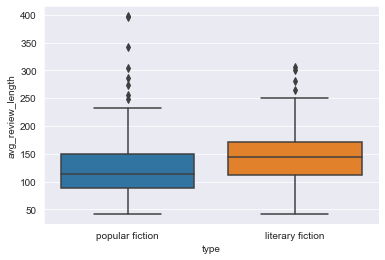

In [42]:
sns.boxplot(data=df,x='type',y='avg_review_length')
plt.savefig('review_length.png',dpi=300)

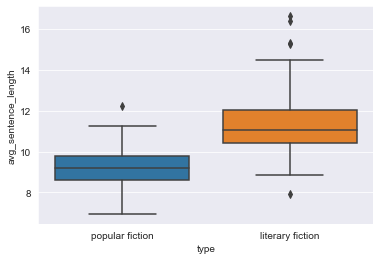

In [43]:
sns.boxplot(data=df,x='type',y='avg_sentence_length')
plt.savefig('sentence_length.png',dpi=300)

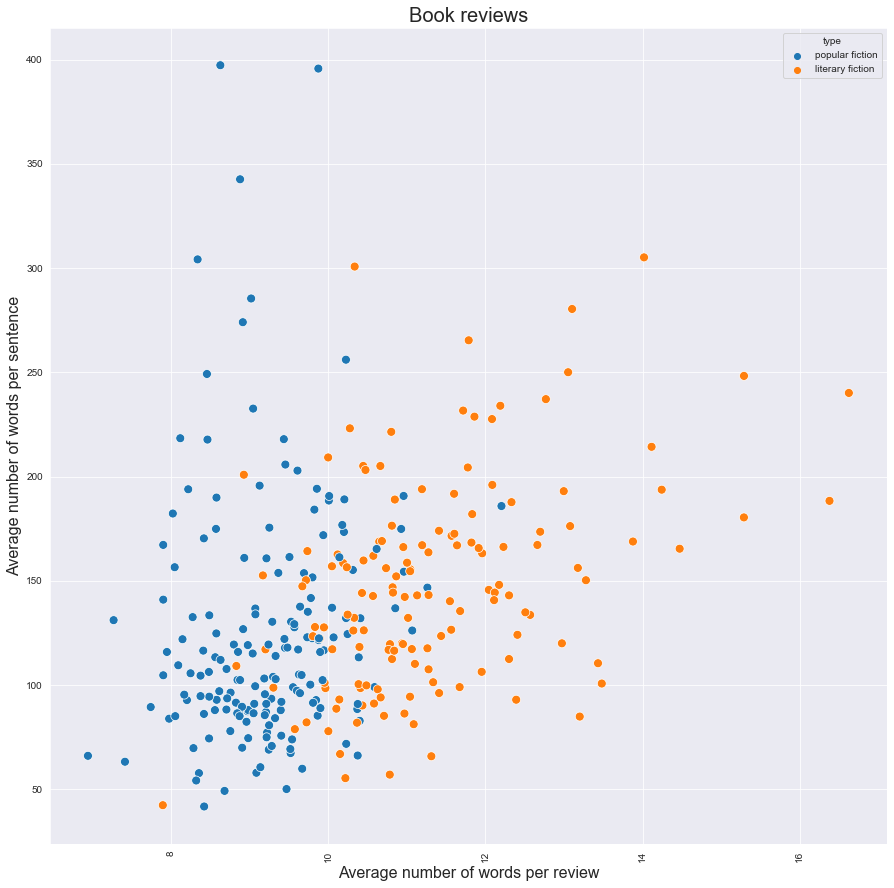

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")

fig = plt.figure( figsize=( 15 , 15 ) )

colours = [ '#c7c4af' , '#0e9e30', '#a0061a' , '#6a55d4' , '#cf8817'  ] 

graph = sns.scatterplot( data= df , 
                        x='avg_sentence_length', 
                        y='avg_review_length' ,
                       hue = 'type', 
                       s = 80 )

graph.set_title('Book reviews' , size = 20) 
graph.set_xlabel('Average number of words per review' , size = 16) 
graph.set_ylabel('Average number of words per sentence' , size = 16 )

plt.xticks(rotation= 90)
# The next line places the legend outside out the plot
#plt.legend( bbox_to_anchor=(1.05, 1),loc=2, borderaxespad=0.);


plt.savefig('sentence_review_length.png',dpi=300)


## Emojis

In [30]:
lf_emoji_freq = Counter()

all_emojis = []
for review in corpus_literary:
    for char in review:
        if is_emoji(char):
            all_emojis.append(char)
            
lf_emoji_freq = Counter(all_emojis)

pf_emoji_freq = Counter()

all_emojis = []
for review in corpus_popular:
    for char in review:
        if is_emoji(char):
            all_emojis.append(char)
            
pf_emoji_freq = Counter(all_emojis)

In [31]:
for emoji,count in pf_emoji_freq.most_common(30):
    print(f"{emoji} ({count})")

⭐ (1126)
😭 (591)
✨ (426)
🌟 (264)
🎶 (167)
♀ (142)
🏻 (140)
❤ (139)
🏼 (138)
♥ (136)
😂 (134)
🥹 (123)
🔥 (119)
🤭 (117)
🌶 (99)
✅ (90)
🖤 (87)
👀 (83)
🥺 (80)
😩 (80)
🎵 (77)
😅 (72)
😍 (70)
🫶 (62)
📖 (61)
🥰 (60)
💀 (58)
💜 (57)
📚 (56)
🙏 (55)


In [32]:
for emoji,count in lf_emoji_freq.most_common(30):
    print(f"{emoji} ({count})")

⭐ (187)
🌟 (59)
🎄 (24)
☑ (22)
📚 (20)
💔 (18)
❤ (16)
✨ (13)
☸ (12)
👏 (11)
😔 (11)
🥲 (10)
😭 (9)
😢 (9)
🖤 (8)
😊 (8)
♀ (6)
🤷 (6)
📖 (5)
♥ (5)
😍 (5)
🥺 (5)
😂 (5)
🐦 (5)
✅ (5)
🏜 (5)
🥹 (5)
🌎 (4)
🏼 (4)
📸 (4)
